In [1]:
# ================================================
# SHAP Explainability
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load clean data
print("Loading data...")
df = pd.read_csv(r'C:\Users\namey\credit-risk-analysis\data\processed\clean_data.csv')

# Prepare features (same as model notebook)
drop_cols = ['SK_ID_CURR', 'AGE_GROUP', 'LOAN_INCOME_RATIO_CAT']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data ready — X_test shape: {X_test.shape}")

Loading data...
Data ready — X_test shape: (61503, 83)


In [2]:
# Retrain XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Training XGBoost... (2-3 mins)")
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("XGBoost ready!")

Training XGBoost... (2-3 mins)
XGBoost ready!


Calculating SHAP values... (takes 2-3 mins)
SHAP values calculated!


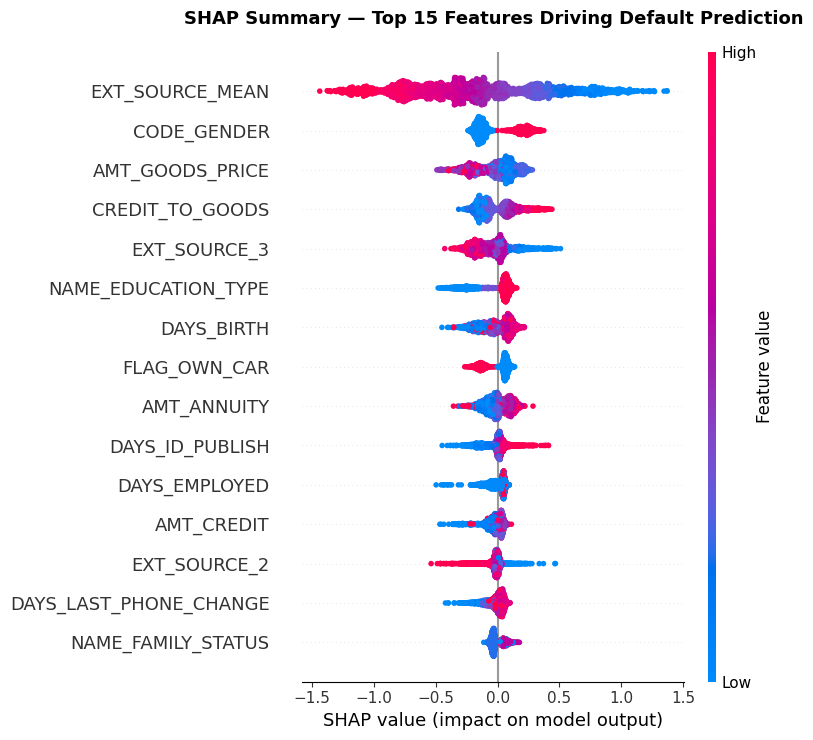

SHAP summary plot saved!


In [3]:
# ================================================
# SHAP Summary Plot
# ================================================

print("Calculating SHAP values... (takes 2-3 mins)")

# Use a sample of 2000 rows for speed
X_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated!")

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Top 15 Features Driving Default Prediction',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(r'C:\Users\namey\credit-risk-analysis\reports\screenshots\08_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved!")

High risk applicants in sample: 605
Showing explanation for applicant index: 584
Predicted default probability: 91.93%


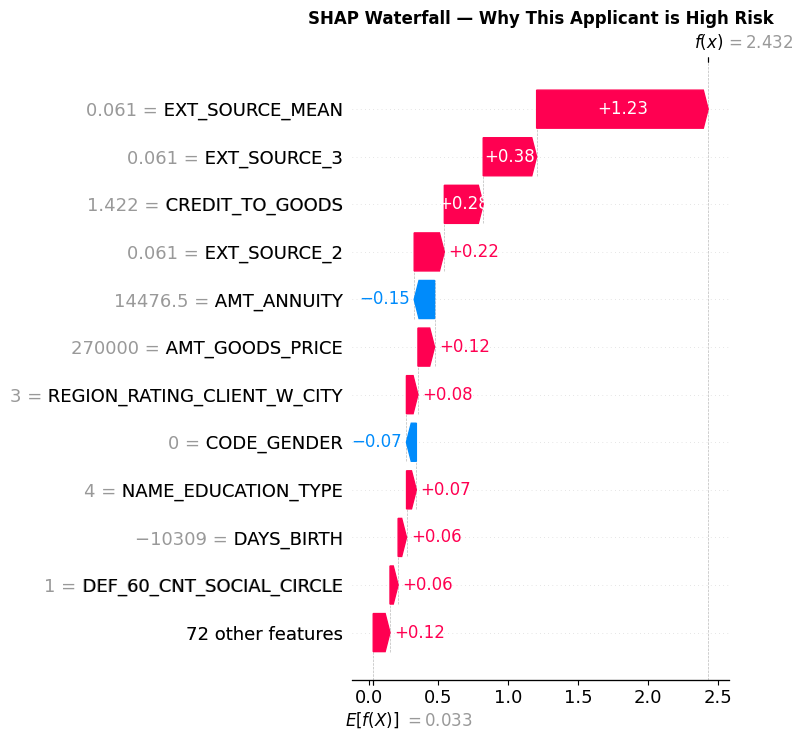

SHAP waterfall plot saved!


In [4]:
# ================================================
# SHAP Waterfall — Single High Risk Applicant
# ================================================

# Find a high risk applicant (predicted default probability > 0.5)
y_pred_proba = xgb_model.predict_proba(X_sample)[:, 1]
high_risk_idx = np.where(y_pred_proba > 0.5)[0]
print(f"High risk applicants in sample: {len(high_risk_idx)}")

# Pick the highest risk one
top_risk = high_risk_idx[np.argmax(y_pred_proba[high_risk_idx])]
print(f"Showing explanation for applicant index: {top_risk}")
print(f"Predicted default probability: {y_pred_proba[top_risk]:.2%}")

# Waterfall plot
explanation = shap.Explanation(
    values=shap_values[top_risk],
    base_values=explainer.expected_value,
    data=X_sample.iloc[top_risk],
    feature_names=X_sample.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title('SHAP Waterfall — Why This Applicant is High Risk',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\namey\credit-risk-analysis\reports\screenshots\09_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP waterfall plot saved!")

RISK SEGMENT SUMMARY
                total  actual_defaults  avg_default_prob  actual_default_rate
RISK_SEGMENT                                                                 
High Risk       16907              455             0.227                 2.69
Low Risk          499                9             0.038                 1.80
Medium Risk      6533               98             0.108                 1.50
Very High Risk  37564             4403             0.522                11.72

 Risk segments saved to data/processed/risk_segments.csv


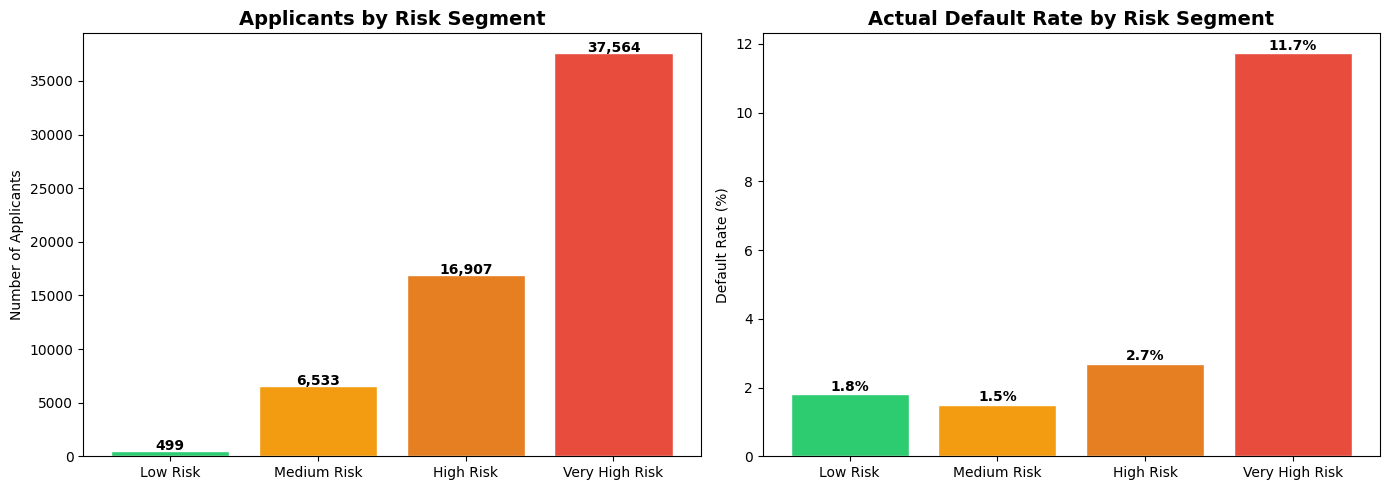

Risk segment plot saved!


In [5]:
# ================================================
# Risk Segmentation
# ================================================

# Score all test applicants
all_proba = xgb_model.predict_proba(X_test)[:, 1]

# Create risk segments
def risk_segment(prob):
    if prob < 0.05:
        return 'Low Risk'
    elif prob < 0.15:
        return 'Medium Risk'
    elif prob < 0.30:
        return 'High Risk'
    else:
        return 'Very High Risk'

X_test_copy = X_test.copy()
X_test_copy['DEFAULT_PROB'] = all_proba
X_test_copy['RISK_SEGMENT'] = X_test_copy['DEFAULT_PROB'].apply(risk_segment)
X_test_copy['ACTUAL_TARGET'] = y_test.values

# Summary
segment_summary = X_test_copy.groupby('RISK_SEGMENT').agg(
    total=('ACTUAL_TARGET', 'count'),
    actual_defaults=('ACTUAL_TARGET', 'sum'),
    avg_default_prob=('DEFAULT_PROB', 'mean')
).round(3)
segment_summary['actual_default_rate'] = (
    segment_summary['actual_defaults'] / segment_summary['total'] * 100
).round(2)

print("=" * 60)
print("RISK SEGMENT SUMMARY")
print("=" * 60)
print(segment_summary)

# Save segments
save_path = r'C:\Users\namey\credit-risk-analysis\data\processed\risk_segments.csv'
X_test_copy[['DEFAULT_PROB', 'RISK_SEGMENT', 'ACTUAL_TARGET',
             'DEBT_TO_INCOME', 'AMT_CREDIT', 'AMT_INCOME_TOTAL',
             'AGE_YEARS', 'YEARS_EMPLOYED']].to_csv(save_path, index=False)
print(f"\n Risk segments saved to data/processed/risk_segments.csv")

# Plot
segment_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
counts = [segment_summary.loc[s, 'total'] if s in segment_summary.index else 0
          for s in segment_order]
default_rates = [segment_summary.loc[s, 'actual_default_rate']
                 if s in segment_summary.index else 0
                 for s in segment_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[0].bar(segment_order, counts, color=colors, edgecolor='white')
axes[0].set_title('Applicants by Risk Segment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Applicants')
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(segment_order, default_rates, color=colors, edgecolor='white')
axes[1].set_title('Actual Default Rate by Risk Segment',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(default_rates):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\namey\credit-risk-analysis\reports\screenshots\10_risk_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Risk segment plot saved!")